In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import subprocess as sub
import time
from scipy.optimize import differential_evolution
#plt.style.use('seaborn-v0_8-whitegrid')
plt.style.use('default')
G = 6.6742e-8
C = 2.99792458e10
Msun = 1.9891e33

In [2]:
sub.run('make quasik')

CompletedProcess(args='make quasik', returncode=0)

In [2]:
N_spins = 6
N_dens = 21
r_ratios = np.linspace(0.99, 0.75, N_spins)
eoss = np.array(pd.read_csv('../eos/max_dens.csv', header=None))
eos_names = eoss[:,0]
min_dens = eoss[:,1]
max_dens = eoss[:,2]

In [29]:
class Eos_Set():

    def __init__(self, eos_name):

        self.name = eos_name
        self.data = np.load("star_data_"+eos_name+'.npy')
        
    def z_model(self, M_R, spin, a):

        return 1/np.sqrt(1-2*M_R)*(1+a*spin**2)-1

    def a(self, M_R, c1, c2):

        return np.exp(c1*M_R**2+c2*M_R)-1

    def z_total(self, i_r):

        M_R = self.data[:, i_r, 4]
        z_total = self.data[:, i_r, 6]

        return [M_R, z_total]
    
    def z_empirical(self, i_r, c1, c2):

        M_R = self.data[:, i_r, 4]
        spins = self.data[:, i_r, 5]
        z_emp = self.z_model(M_R, spins, self.a(M_R, c1, c2))

        return [M_R, z_emp]
    
    def filter_index(self, i_r):

        massrange = [0.9, 2.4]
        spinrange = [0, 800]

        i_m = np.where((self.data[:, i_r, 3] > massrange[0]) & (self.data[:, i_r, 3] < massrange[1]))[0]
        i_s = np.where((self.data[:, i_r, 5] > spinrange[0]) & (self.data[:, i_r, 5] < spinrange[1]))[0]
        indices = np.zeros(i_m.size + i_s.size)
        indices[:i_m.size] = i_m
        indices[i_m.size:] = i_s
        if indices.size != N_dens:
            print('filtered')
        return indices.astype(int)
    
    def test_fit(self, c1, c2, show=False):
        redshift_error = np.zeros([N_dens,N_spins])

        for j in range(6):

            i_ = self.filter_index(j)
            z_t = self.data[i_, j, 6]
            mr = self.data[i_, j, 4]
            spn = self.data[i_, j, 5]
            z_e = self.z_model(mr, spn, self.a(mr, c1, c2))

            z_err = np.abs(z_e-z_t)/z_t

            redshift_error[:, j] = z_err[:]

        residual = np.sum(redshift_error**2)

        if (show):

            M_R = np.zeros(N_dens+1)
            M_R[1:] = self.data[:, 5, 4]
            r_r = np.zeros(N_spins+1)
            r_r[0] = 1
            r_r[1:] = r_ratios

            plt.figure()
            plt.pcolormesh(M_R, r_r, redshift_error.transpose()*100, cmap='plasma', vmin=0, shading='flat')
            plt.colorbar(label='squared residual')
            plt.xlabel('$M/R$')
            plt.ylabel('$r_{e}/r_{p}$')
            plt.title("eos"+self.name)
            plt.show()

            print("error = "+str(residual))

        return residual

    def plot_fit(self, c1, c2, i_r):

        M_R = self.data[:, i_r, 4]
        spins = self.data[:, i_r, 5]
        z_total = self.data[:, i_r, 6]
        z_emp = self.z_model(M_R, spins, self.a(M_R, c1, c2))

        plt.figure()
        plt.plot(M_R, z_total, c='r', alpha=0.7, label='total redshift')
        plt.plot(M_R, z_emp, c='g', alpha=0.5, label='empirical redshift')
        plt.xlabel('$M/R$')
        plt.ylabel('z_eq')
        plt.title("eos "+self.name+", $r_e/r_p = $"+str(r_ratios[i_r]))
        plt.legend()
        plt.show()
    
    def fit_LSQ(self):

        x = np.zeros([N_dens*N_spins, 2])
        y = np.zeros([N_dens*N_spins])

        fillfrom = 0

        for i_r in range(N_spins):
            
            i_ = self.filter_index(i_r)
            mr = self.data[i_, i_r, 4]
            spn = self.data[i_, i_r, 5]
            z = self.data[i_, i_r, 6]

            fillrange = np.arange(fillfrom, fillfrom+N_dens, 1)
            xfill = np.array([mr, mr**2]).transpose()
            yfill = np.log((1/spn**2)*((1+z)*np.sqrt(1-2*mr)-1))

            x[fillrange, :] = xfill
            y[fillrange] = yfill
            
            fillfrom += N_dens

        xT = np.transpose(x)
        xTx = np.dot(xT, x)
        xTxinv = np.linalg.inv(xTx)
        A = np.dot(xTxinv, xT)
        coefs = np.dot(A, y)
        
        return coefs
    
    def bruteforce(self):
        steps = 50
        c1_range = np.linspace(0, 3, steps)
        c2_range = np.linspace(0, 1, steps)
        fit_errors = np.zeros([steps, steps])

        for ic1 in range(steps):
            for ic2 in range(steps):
                fit_errors[ic1, ic2] = self.test_fit(c1_range[ic1], c2_range[ic2], False)
        min = fit_errors.min()
        indices = np.where(fit_errors == min)
        c1 = c1_range[indices[0]][0]
        c2 = c2_range[indices[1]][0]
        coefs = np.array([c2, c1])

        plt.figure()
        plt.imshow(fit_errors)
        plt.xlabel('c1 from 0 to 3')
        plt.ylabel('c2 from 0 to 1')
        plt.colorbar(label='residuals')

        return coefs
    
    def diff_evo_obj(self, params):

        c1, c2 = params
        return self.test_fit(c1, c2, show=False)
    
    def diff_evo(self):

        bounds = [(0, 10), (0, 10)]
        result = differential_evolution(self.diff_evo_obj, bounds)
        c1, c2 = result.x
        coefs = np.array([c2, c1])

        return coefs 

    def plot_quad(self, i_r):

        M = self.data[:, i_r, 3]
        #R = self.data[:, i_r, 2]
        M_R = self.data[:, i_r, 4]
        #quad = self.data[:, i_r, 7]
        a = self.data[:, i_r, 8]
        eps = self.data[:, i_r, 9]

        q = -eps-a**2
        
        quad_corr = a**2*(4.3)

        skip = 3
        plt.figure()
        plt.plot(M[skip:]/Msun, quad_corr[skip:], label='$a^2(1+3.3)$ ')#+str(r_ratios[i_r]))
        plt.plot(M[skip:]/Msun, -q[skip:], label='q ')#+str(r_ratios[i_r]))
        #plt.plot(M[skip:]/Msun, 3.3*np.ones(N_dens-skip), label='$\eta = 3.3$ ')#+str(r_ratios[i_r]))
        #plt.plot(M[skip:]/Msun, -q[skip:]/a[skip:]**2-1, label='$\eta$ from q')#+str(r_ratios[i_r]))
        
        plt.xlabel('$M/M_\odot$')
        plt.ylabel('dimensionless q')
        plt.title("eos "+self.name+", $r_p/r_e$ = "+str(r_ratios[i_r]))
        plt.legend()

        plt.show()

In [30]:
Eos_array = np.empty(eos_names.size, dtype=object)

for j in range(eos_names.size):

    Eos_array[j] = Eos_Set(eos_names[j])

In [ ]:
for Eos in Eos_array:

    Eos.plot_quad(1)

brute force residuals =  0.010308520559920138
differential evolution residuals =  0.008309068943247632


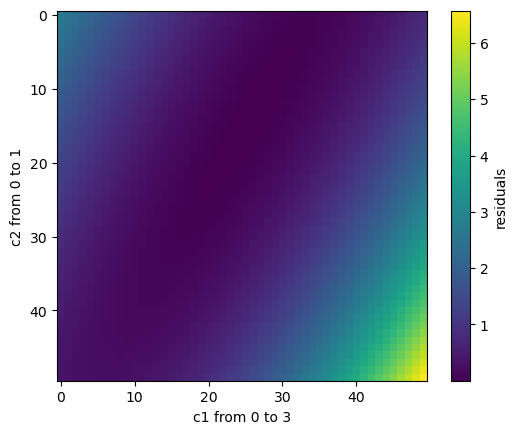

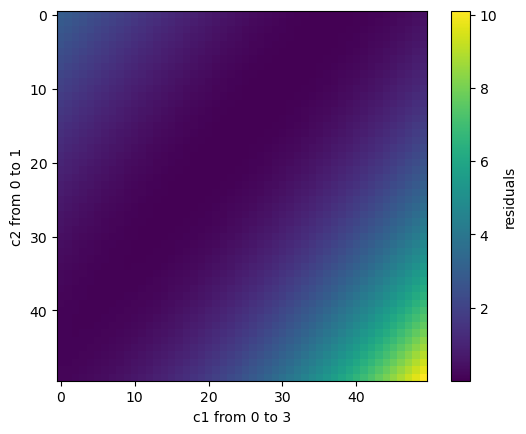

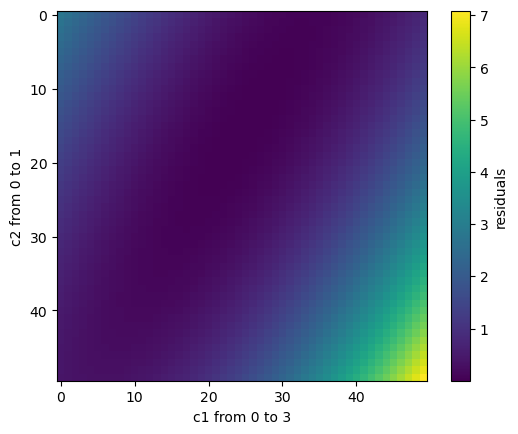

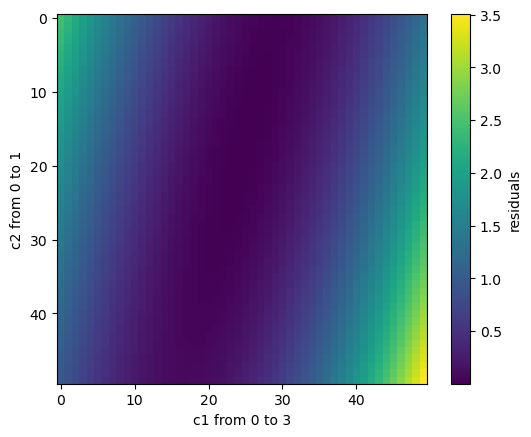

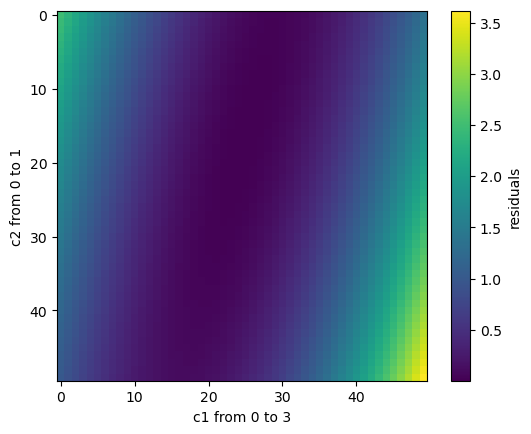

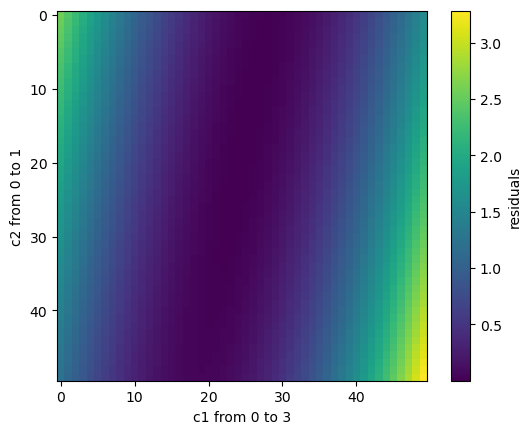

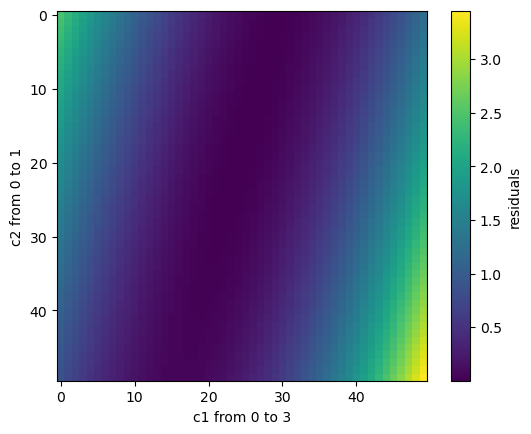

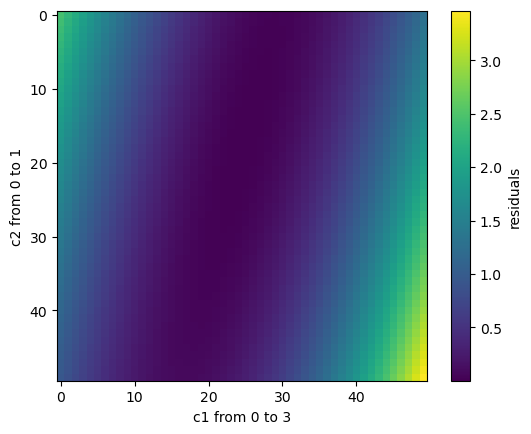

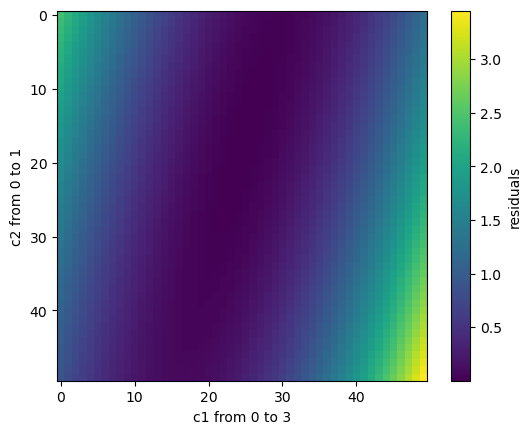

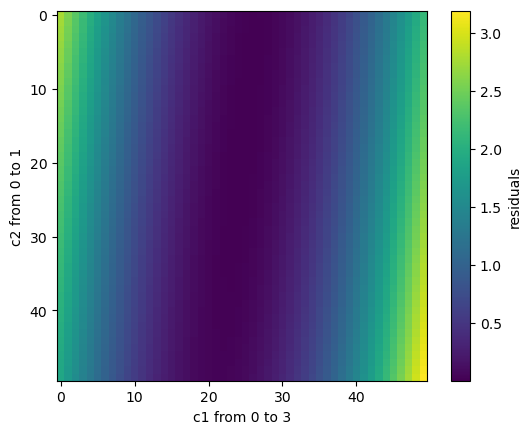

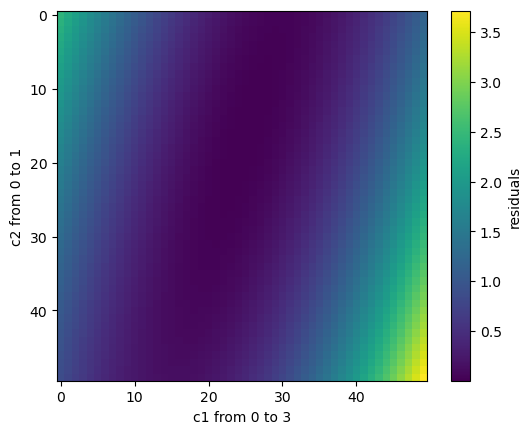

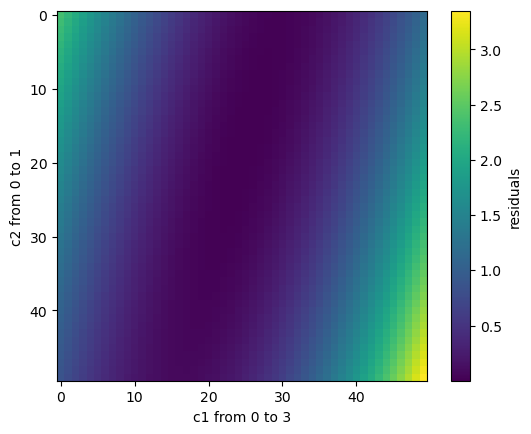

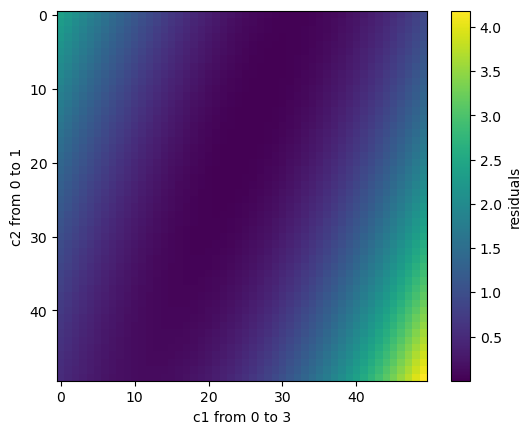

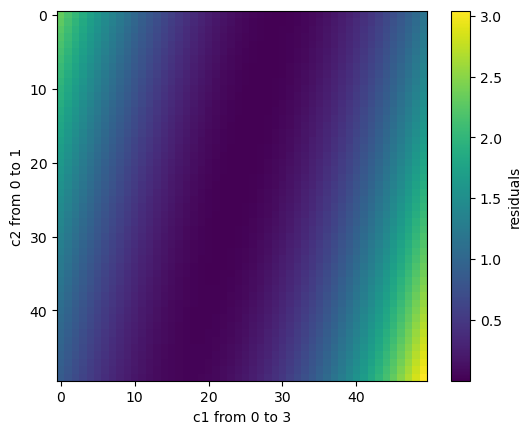

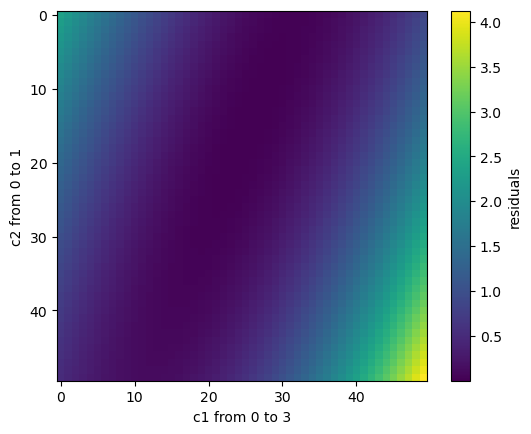

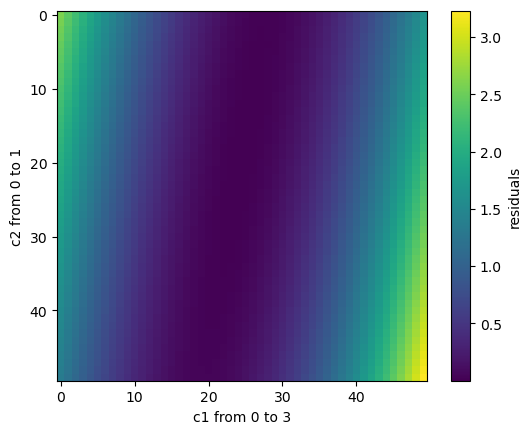

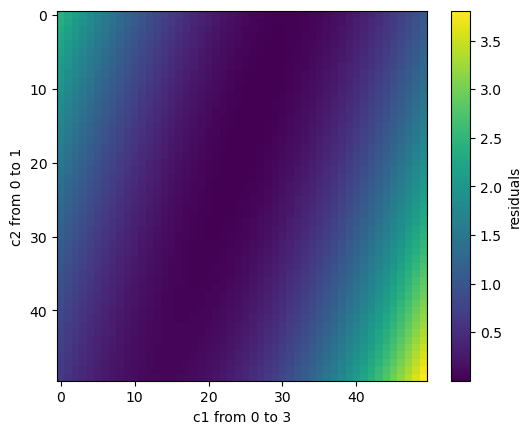

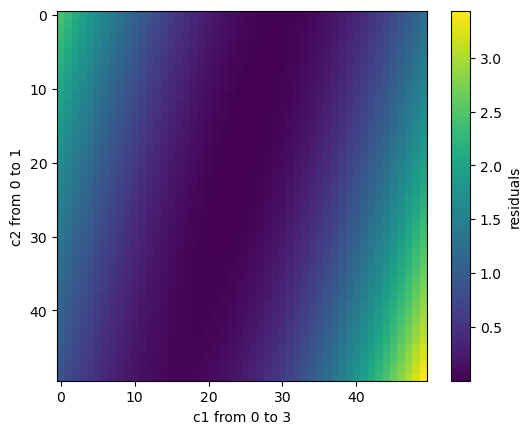

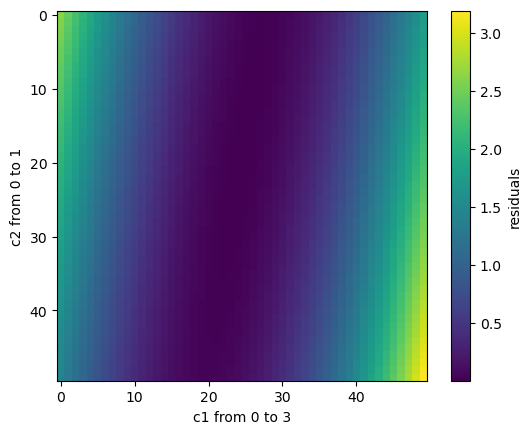

In [36]:
res_o = 0
#res_ls = 0
res_de = 0

for Eos in Eos_array:

    coefs_o = Eos.bruteforce()
    #coefs_ls = Eos.fit_LSQ()
    coefs_de = Eos.diff_evo()
    res_o += Eos.test_fit(coefs_o[1], coefs_o[0])
    #res_ls += Eos.test_fit(coefs_ls[1], coefs_ls[0])
    res_de += Eos.test_fit(coefs_de[1], coefs_de[0])

print("brute force residuals = ", res_o)
#print("LSQ residuals =  ", res_ls)
print("differential evolution residuals = ", res_de)


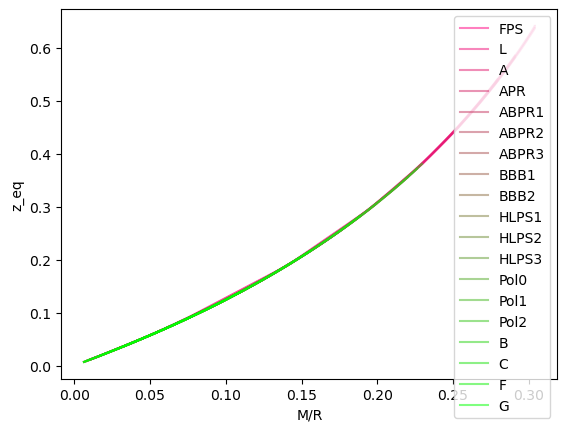

In [8]:
colors = np.linspace((1,0,0.5),(0,1,0),Eos_array.size)
i_r = 1
#for i_r in range(6):
c=0
for k in range(Eos_array.size):

        
    plt.plot(Eos_array[k].data[:, i_r, 4], Eos_array[k].data[:, i_r, 6], alpha=0.5, c=colors[c], label=Eos_array[k].name)
    plt.plot(Eos_array[k].data[:, i_r, 4], Eos_array[k].z_empirical(i_r, 1.252, 0.505)[1], alpha=0.5, c=colors[c])
    c+=1

plt.xlabel('M/R')
plt.ylabel("z_eq")
plt.legend()

In [34]:
def fit_LSQ_all(Eos_array, show=True):

    x = np.zeros([N_dens*N_spins*Eos_array.size, 2])
    y = np.zeros([N_dens*N_spins*Eos_array.size])

    fillfrom = 0

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            mr = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 4]
            spn = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 5]
            z = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 6]

            fillrange = np.arange(fillfrom, fillfrom+N_dens, 1)
            xfill = np.array([mr, mr**2]).transpose()
            yfill = (1/spn**2)*((1+z)*np.sqrt(1-2*mr)-1)

            x[fillrange, :] = xfill
            y[fillrange] = yfill

            fillfrom += N_dens

    xT = np.transpose(x)
    xTx = np.dot(xT, x)
    xTxinv = np.linalg.inv(xTx)
    A = np.dot(xTxinv, xT)
    coefs = np.dot(A, y)

    if (show):
        plt.scatter(x[:,0], y, s=3, c='b', alpha=0.5, label='data')
        xs = x[:,0]
        xs = np.sort(xs, None)
        plt.plot(xs, np.exp(0.937*xs**2+0.514*xs)-1, c='r', label='differential evolution')
        plt.plot(xs, coefs[1]*xs**2+coefs[0]*xs, c='m', label='LSQ fit')
        plt.xlabel('M/R')
        plt.ylabel('$1/\overline{\Omega}^2 ((1+z)\sqrt{1-2M/R)}-1)$')
        plt.legend()
    
    return coefs

In [32]:
def diff_evo_all_obj(params):

    c1, c2 = params

    z_t = np.zeros([N_dens*N_spins*Eos_array.size])
    z_e = np.zeros([N_dens*N_spins*Eos_array.size])
    
    fillfrom = 0

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            mr = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 4]
            spn = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 5]
            z_t_fill = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 6]

            fillrange = np.arange(fillfrom, fillfrom+N_dens, 1)
            z_e_fill = (1/np.sqrt(1-2*mr))*(1+spn**2*(np.exp(c1*mr**2+c2*mr)-1))-1

            z_t[fillrange] = z_t_fill
            z_e[fillrange] = z_e_fill

            fillfrom += N_dens

    residual = np.sum(((z_t-z_e)/z_t)**2)

    return residual

def diff_evo_all():

    bounds = [(0, 5), (0, 5)]
    result = differential_evolution(diff_evo_all_obj, bounds)
    c1, c2 = result.x
    coefs = np.array([c2, c1])

    return coefs

In [33]:
diff_evo_all()

array([0.51358828, 0.93799874])

array([0.53688897, 1.00313327])

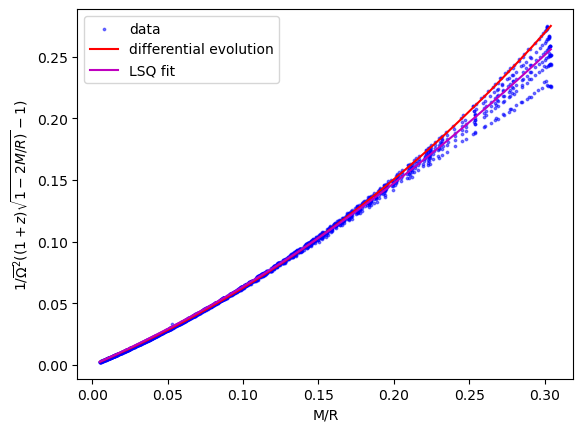

In [35]:
fit_LSQ_all(Eos_array)

In [35]:
sub.run('make quasik')

CompletedProcess(args='make quasik', returncode=0)

In [36]:
sub.run('quasik.exe -f "../eos/eosFPS" -e 9e14 -r 0.9 -i 90', capture_output=True)

CompletedProcess(args='quasik.exe -f "../eos/eosFPS" -e 9e14 -r 0.9 -i 90', returncode=0, stdout=b'EOS file: ../eos/eosFPS, Grid size = MDIVxSDIV = 151x301\r\n\r\ne_center = 0.9e15 g/cm^3\r\nr_ratio  = 0.9\r\nMass     = 1.06038 MSUN\r\nM/R      = 0.13338 \r\nR_e      = 11.7432 km\r\nSpin     = 583.207 Hz\r\nj = a/M  = J/M^2 = 0.335197 \r\n\r\nQuadrupole: Laarakkers and Poisson \r\nQuadrupole = -4.23361e+43 g cm^2 \r\nqscale = -0.81817 \r\nmscale = -0.830742 \r\nLP formula: q = -0.483135 \r\nQuasiKerr dimensionless quadrupole parameter: epsilon = 0.705813 \r\n\r\nComparison of QuasiKerr Metric with numerical RNS metric\r\nOmega = 3664.397022, Omega_K = 9324.041080\r\nSch (1+z) = 0.843882  RNS (1+z) = 0.844633 \r\n Fractional diff in Flux = -0.00266348\r\n', stderr=b'')

In [37]:
redshifts = np.array(pd.read_csv('redshift.csv'))

mu = redshifts[:,0]

z_0 = redshifts[:,1]
z_max = redshifts[:,2]
z_min = redshifts[:,3]

z_sch = redshifts[:,4]
z_grav = redshifts[:,5]

z_sd_0 = redshifts[:,6]
z_sd_max = redshifts[:,7]
z_sd_min = redshifts[:,8]
gamma = redshifts[:,9]

z_schv = 1/redshifts[:,10]-1
z_ker = 1/redshifts[:,11]-1
z_quk = 1/redshifts[:,12]-1

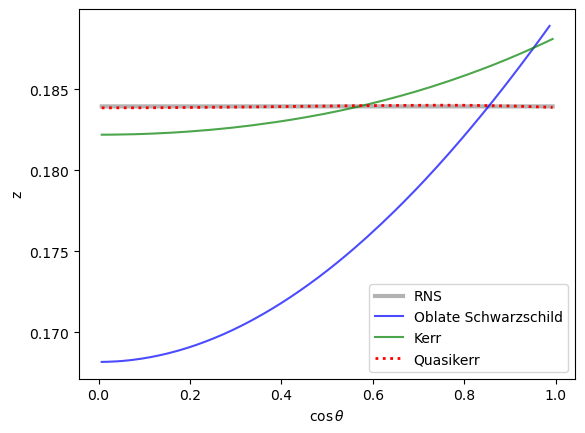

In [38]:
fig, ax = plt.subplots()
ax.plot(mu, z_0, c='k', alpha=0.3, lw=3, label='RNS')
#ax.plot(mu, z_sch, c='m', alpha=0.7, label='Schwarzschild')
#ax.plot(mu, z_grav, c='c', alpha=0.7, label='$ RNS \ g_{tt}$')
ax.plot(mu[:-1], z_sd_0[:-1], c='b', alpha=0.7, label='Oblate Schwarzschild')
#ax.plot(mu, z_schv, c='brown', alpha=0.7, label='$Sch/\gamma$')
ax.plot(mu, z_ker, c='g', alpha=0.7, label='Kerr')
ax.plot(mu, z_quk, c='r', alpha=1, lw=2, linestyle=':', label='Quasikerr')
plt.xlabel(r"$\cos\theta$")
plt.ylabel('z')
#ax.set_ylim(0, 0.3)
ax.legend(loc='lower right')
#plt.savefig('output.png', dpi=390)

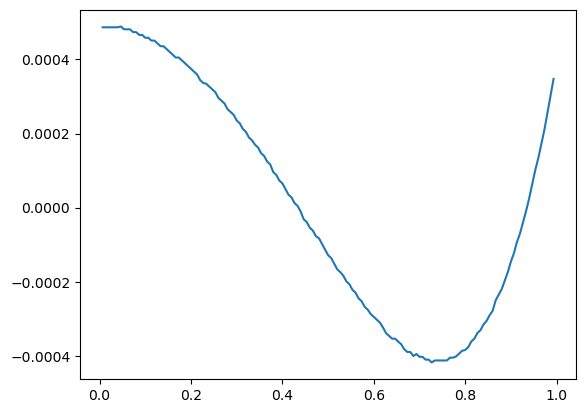

In [39]:
plt.plot(mu, (z_0-z_quk)/z_0)

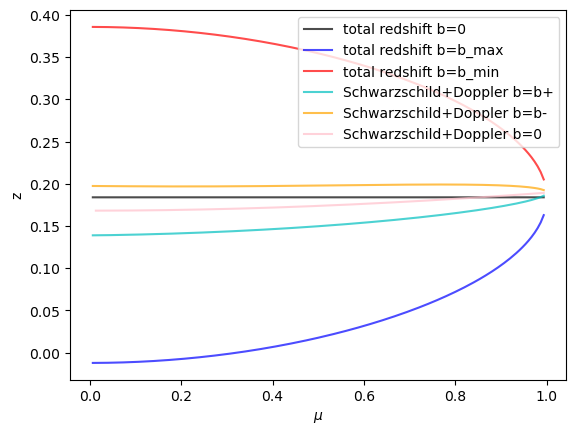

In [40]:
fig, ax = plt.subplots()
ax.plot(mu, z_0, c='k', alpha=0.7, label='total redshift b=0')
ax.plot(mu, z_max, c='b', alpha=0.7, label='total redshift b=b_max')
ax.plot(mu, z_min, c='r', alpha=0.7, label='total redshift b=b_min')
ax.plot(mu, z_sd_min, c='c', alpha=0.7, label='Schwarzschild+Doppler b=b+')
ax.plot(mu, z_sd_max, c='orange', alpha=0.7, label='Schwarzschild+Doppler b=b-')
ax.plot(mu[1:], z_sd_0[1:], c='pink', alpha=0.7, label='Schwarzschild+Doppler b=0')
plt.xlabel('$\mu$')
plt.ylabel('z')
#ax.set_ylim(0, 0.3)
ax.legend()

In [41]:
data = np.array(pd.read_csv('surface.csv'))
mu = data[:,0]
r_surf = data[:,1]

x = r_surf*np.sqrt(1-mu**2)
y = r_surf*mu

Text(0, 0.5, 'polar radius (km)')

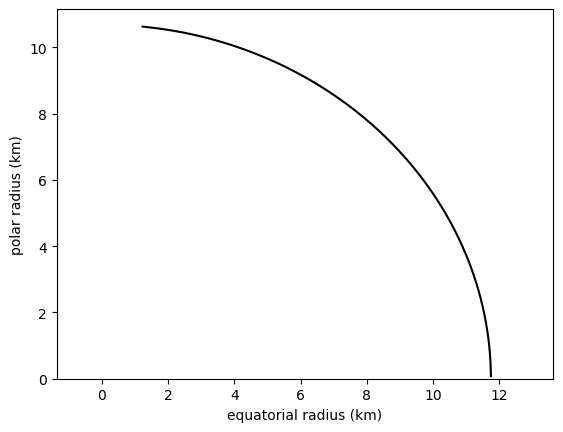

In [42]:
fig, ax = plt.subplots()
ax.plot(x, y, c='k')
ax.axis('equal')
ax.set_xlim(0, None)
ax.set_ylim(0, None)
plt.xlabel('equatorial radius (km)')
plt.ylabel('polar radius (km)')

In [43]:
def find_range(eos_name, i_r):

    de = 5e13
    e_min = 1e14-de
    star_M = 0
    while (star_M < 0.9*Msun):

        e_min += de
        string = 'quasik.exe -f "../eos/eos' + eos_name + '" -e ' + "{:e}".format(e_min).replace('+', '') + ' -r ' + str(r_ratios[i_r])
        sub.run(string)
        output = np.loadtxt('star.csv', delimiter=',')
        if (output[3]/star_M <= 1.01):
            break
        star_M = output[3]
        print('e = %e, M = %e' % (e_min, star_M/Msun))
    print('minimum found: e = %e, M = %e' % (e_min, star_M/Msun))

    e_max = 1e15-de
    star_M = 0
    while (star_M < 2.4*Msun):

        e_max += de
        string = 'quasik.exe -f "../eos/eos' + eos_name + '" -e ' + "{:e}".format(e_min).replace('+', '') + ' -r ' + str(r_ratios[i_r])
        sub.run(string)
        output = np.loadtxt('star.csv', delimiter=',')
        if (output[3]/star_M <= 1.01):
            break
        star_M = output[3]
        print('e = %e, M = %e' % (e_max, star_M/Msun))
    print('maximum found: e = %e, M = %e' % (e_max, star_M/Msun))

    return [e_min, e_max]

In [44]:
def create_dataset(eos, e_max):
    ratios = np.linspace(0.99, 0.75, N_spins)
    densities = np.linspace(3e14, e_max, N_dens)

    star_data = np.zeros([N_dens, N_spins, 10])
    i_r=0
    t_0 = time.time()
    for r in ratios:
        i_e = 0
        for e in densities:
            string = 'quasik.exe -f "../eos/eos' + eos + '" -e ' + "{:e}".format(e).replace('+', '') + ' -r ' + str(r)
            sub.run(string)
            output = np.loadtxt('star.csv', delimiter=',')
            star_data[i_e,i_r,:] = output
            print(eos+'  %i, %i ' % (i_r, i_e), end='\r')
            i_e += 1
        i_r += 1
    np.save('star_data_'+eos, star_data)
    t_f = time.time()
    t_min = round((t_f-t_0)/60, 2)
    print(eos+' done in '+str(t_min)+' minutes')
    return

In [ ]:
for i in range(eos_names.size):
    try:
        create_dataset(eos_names[i], max_dens[i])
    except ValueError:
        print(str(eos_names[i])+' failed due to ValueError')
    except TypeError:
        print(str(eos_names[i])+' failed due to TypeError')
    except Exception:
        print(str(eos_names[i])+' failed due to Exception')

In [ ]:
while True:
    
    print('Will it work?')
    a = input('')
    s = time.time()*1e7 % 3

    if (s!=0):
        print('Yes!')
    else:
        raise Exception('No.')

    print('')

    if (a=='x'):
        break